In [13]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATH = "../aca-butterflies"
NUM_CLASSES = 75
BATCH_SIZE = 32
IMAGE_SIZE = 224 # standard for pretrained ResNets
NUM_EPOCHS = 40
PATIENCE = 7

# since we are using pre trained resNets we decided to normalize it using this values 
# discussion of value origin can be found here https://github.com/pytorch/vision/pull/1965
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# from our dataset, calculated at 0_EDA.ipynb file
RGB_MEAN = [0.4790, 0.4646, 0.3369]
RGB_STD = [0.2560, 0.2462, 0.2558]

In [14]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None, class_to_idx=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = class_to_idx if class_to_idx is not None else {
            cls_name: idx for idx, cls_name in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
def build_transforms(mean, std, image_size=IMAGE_SIZE):
    train = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    
    return train, val

In [16]:
train_transform, val_transform = build_transforms(RGB_MEAN, RGB_STD)
train_transform_pre_trained, val_transform_pre_trained = build_transforms(IMAGENET_MEAN, IMAGENET_STD)

img_dir = os.path.join(PATH, "train")
df = pd.read_csv(os.path.join(PATH, "train.csv"))

df_train, df_val = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)

all_classes   = sorted(df["label"].unique())
class_to_idx  = {cls: idx for idx, cls in enumerate(all_classes)}
idx_to_class  = {idx: cls for cls, idx in class_to_idx.items()}

train_dataset = ButterflyDataset(df_train, img_dir, train_transform, class_to_idx)
val_dataset   = ButterflyDataset(df_val, img_dir, val_transform, class_to_idx)

train_dataset_pre = ButterflyDataset(df_train, img_dir, train_transform_pre_trained, class_to_idx)
val_dataset_pre   = ButterflyDataset(df_val, img_dir, val_transform_pre_trained, class_to_idx)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

train_loader_pre_trained = data.DataLoader(train_dataset_pre, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_pre_trained = data.DataLoader(val_dataset_pre, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(df_train.size)
print(df_val.size)

8318
2080


In [17]:
class BasicBlock(nn.Module):
    # He et al., 'Deep Residual Learning for Image Recognition', can be found in ../papers
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # residual addition
        return F.relu(out)


class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        width = out_channels

        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(width)

        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(width)

        self.conv3 = nn.Conv2d(width, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        return F.relu(out)

In [ ]:
class CustomResNet(nn.Module):
    def __init__(self, block, layers, num_classes=75, dropout_p=0.4):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # Weight initialisation (He / Kaiming)
        # Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification by He et al, can be found in ../papers
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


def resnet18_custom(num_classes=75, dropout_p=0.4):
    return CustomResNet(BasicBlock, [2, 2, 2, 2], num_classes, dropout_p)

def resnet34_custom(num_classes=75, dropout_p=0.4):
    return CustomResNet(BasicBlock, [3, 4, 6, 3], num_classes, dropout_p)

def resnet50_custom(num_classes=75, dropout_p=0.4):
    return CustomResNet(BottleneckBlock, [3, 4, 6, 3], num_classes, dropout_p)



In [19]:
def build_pretrained_resnet(variant="resnet18", strategy="finetune", num_classes=75, dropout_p=0.4):
    weights_map = {
        "resnet18": models.ResNet18_Weights.DEFAULT,
        "resnet50": models.ResNet50_Weights.DEFAULT,
    }
    constructor_map = {
        "resnet18": models.resnet18,
        "resnet50": models.resnet50,
    }

    model = constructor_map[variant](weights=weights_map[variant])

    if strategy == "freeze":
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )
    return model


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds, all_logits = [], [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_logits.append(outputs.cpu())

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), torch.cat(all_logits)

In [ ]:
def compute_metrics(labels, preds, logits, name=""):
    acc = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average="macro", zero_division=0)
    f1_wei = f1_score(labels, preds, average="weighted", zero_division=0)

    logits_t = torch.tensor(logits)
    labels_t = torch.tensor(labels)
    _, top5 = logits_t.topk(5, dim=1)
    top5_acc = top5.eq(labels_t.view(-1, 1).expand_as(top5)).any(dim=1).float().mean().item()

    print(f"{name}->Accuracy : {acc:.4f}")
    print(f"{name}->Top-5    : {top5_acc:.4f}")
    print(f"{name}->F1 (macro)    : {f1_mac:.4f}")
    print(f"{name}->F1 (weighted) : {f1_wei:.4f}")
    return {"accuracy": acc, "top5_accuracy": top5_acc, "f1_macro": f1_mac, "f1_weighted": f1_wei}


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=NUM_EPOCHS, patience=PATIENCE, device=DEVICE, run_name="experiment"):
    counter_early_stopper = 0
    best_weights = None
    best_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "train_acc":  [], "val_acc":  []}

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}")
        
        if vl_loss < best_loss - 1e-4:
            best_loss = vl_loss
            best_weights = copy.deepcopy(model.state_dict())
            counter_early_stopper = 0
        else:
            counter_early_stopper += 1
            if counter_early_stopper >= patience:
                print(f"Early stopped at epoch {epoch}")
                break

    elapsed = time.time() - t0
    elapsed_in_min = elapsed/60
    print(f"Training complete in {elapsed_in_min:.1f} minutes")

    model.load_state_dict(best_weights)
    return model, history, elapsed_in_min

In [22]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
def build_optimizer(name, params, lr, weight_decay=1e-4):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    elif name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)



def build_criterion(name):
    if name == "cross_entropy":
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif name == "multi_margin":
        return nn.MultiMarginLoss(margin=1.0)

exp = [
    ("pretrained_resnet50_ce_adam", lambda: build_pretrained_resnet("resnet50", "finetune"), "cross_entropy", "adam", 1e-4, 1),
    ("pretrained_resnet50_ce_adam_low_lr", lambda: build_pretrained_resnet("resnet50", "finetune"), "cross_entropy", "adam", 5e-5, 1),
    ("pretrained_resnet18_ce_adam", lambda: build_pretrained_resnet("resnet18", "finetune"), "cross_entropy", "adam", 1e-4, 1),
    ("pretrained_resnet50_ce_rmsprop", lambda: build_pretrained_resnet("resnet50", "finetune"), "cross_entropy", "rmsprop", 1e-4, 1),
    ("pretrained_resnet50_mm_adam", lambda: build_pretrained_resnet("resnet50", "finetune"), "multi_margin", "adam", 1e-4, 1),
    ("pretrained_resnet18_ce_rmsprop", lambda: build_pretrained_resnet("resnet18", "finetune"), "cross_entropy", "rmsprop", 1e-4, 1),
    ("pretrained_resnet18_mm_adam", lambda: build_pretrained_resnet("resnet18", "finetune"), "multi_margin", "adam", 1e-4, 1),
    ("custom_resnet50_ce_adam", lambda: resnet50_custom(), "cross_entropy", "adam", 1e-3, 0),
    ("custom_resnet50_ce_adam_low_lr", lambda: resnet50_custom(), "cross_entropy", "adam", 5e-4, 0),
    ("custom_resnet18_ce_adam", lambda: resnet18_custom(), "cross_entropy", "adam", 1e-3, 0),
    ("custom_resnet34_ce_adam", lambda: resnet34_custom(), "cross_entropy", "adam", 1e-3, 0),
    ("custom_resnet50_mm_adam", lambda: resnet50_custom(), "multi_margin", "adam", 1e-3, 0),
    ("custom_resnet18_mm_adam", lambda: resnet18_custom(), "multi_margin", "adam", 1e-3, 0),
    ("custom_resnet50_ce_rmsprop", lambda: resnet50_custom(), "cross_entropy", "rmsprop", 1e-3, 0),
    ("custom_resnet18_ce_rmsprop", lambda: resnet18_custom(), "cross_entropy", "rmsprop", 1e-3, 0),
    ("custom_resnet18_mm_adamw", lambda: resnet18_custom(), "multi_margin", "adamw", 1e-3, 0),
    ("custom_resnet34_mm_adamw", lambda: resnet34_custom(), "multi_margin", "adamw", 1e-3, 0),
    ("pretrained_resnet50_freezed_ce_adam", lambda: build_pretrained_resnet("resnet50", "freeze"), "cross_entropy", "adam", 1e-4, 1),
    ("custom_resnet50_mm_adamw", lambda: resnet50_custom(), "multi_margin", "adamw", 1e-3, 0),
    ("pretrained_resnet18_freezed_ce_adam", lambda: build_pretrained_resnet("resnet18", "freeze"), "cross_entropy", "adam", 1e-4, 1)
]

-------------------------------------
Run: custom_resnet18_mm_adamw
Loss: multi_margin  |  Optimizer: adamw  |  LR: 0.001
----------------------------------------------
Epoch   1/40 | Train loss: 0.6314 acc: 0.0647 | Val loss: 0.3484 acc: 0.1144
Epoch   2/40 | Train loss: 0.3664 acc: 0.1166 | Val loss: 0.2668 acc: 0.1827
Epoch   3/40 | Train loss: 0.2954 acc: 0.1428 | Val loss: 0.2219 acc: 0.2375
Epoch   4/40 | Train loss: 0.2302 acc: 0.1991 | Val loss: 0.1630 acc: 0.2913
Epoch   5/40 | Train loss: 0.2004 acc: 0.2188 | Val loss: 0.1485 acc: 0.2981
Epoch   6/40 | Train loss: 0.1658 acc: 0.2635 | Val loss: 0.1286 acc: 0.3481
Epoch   7/40 | Train loss: 0.1491 acc: 0.2878 | Val loss: 0.1094 acc: 0.4240
Epoch   8/40 | Train loss: 0.1316 acc: 0.3220 | Val loss: 0.1378 acc: 0.3490
Epoch   9/40 | Train loss: 0.1271 acc: 0.3421 | Val loss: 0.0977 acc: 0.4125
Epoch  10/40 | Train loss: 0.1081 acc: 0.3669 | Val loss: 0.0860 acc: 0.4510
Epoch  11/40 | Train loss: 0.0981 acc: 0.4030 | Val loss: 0.0

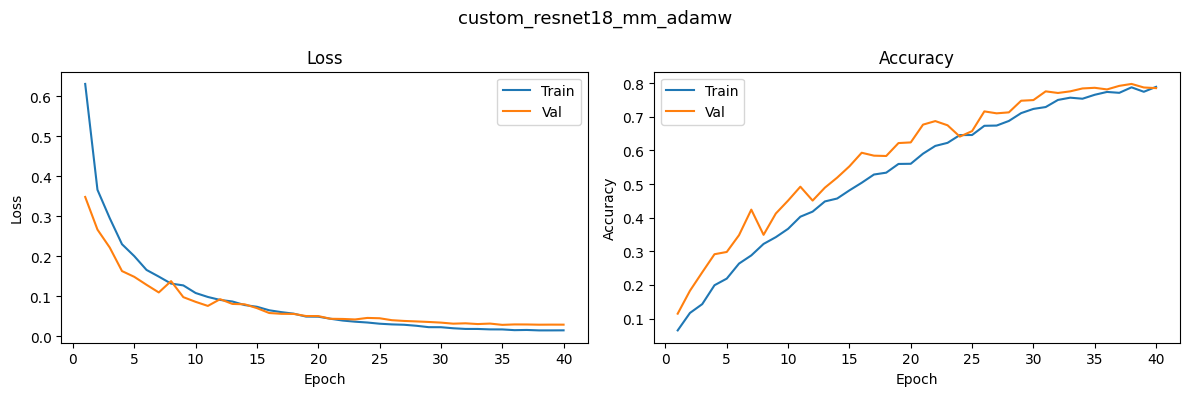

Checkpoint saved: checkpoints_ResNets_2026/custom_resnet18_mm_adamw.pt
-------------------------------------
Run: custom_resnet34_mm_adamw
Loss: multi_margin  |  Optimizer: adamw  |  LR: 0.001
----------------------------------------------
Epoch   1/40 | Train loss: 0.7927 acc: 0.0327 | Val loss: 0.4725 acc: 0.0712
Epoch   2/40 | Train loss: 0.5078 acc: 0.0659 | Val loss: 0.3592 acc: 0.1058
Epoch   3/40 | Train loss: 0.4109 acc: 0.0971 | Val loss: 0.2693 acc: 0.1673
Epoch   4/40 | Train loss: 0.3413 acc: 0.1315 | Val loss: 0.3489 acc: 0.1490
Epoch   5/40 | Train loss: 0.2937 acc: 0.1368 | Val loss: 0.1888 acc: 0.2558
Epoch   6/40 | Train loss: 0.2389 acc: 0.1767 | Val loss: 0.1760 acc: 0.2106
Epoch   7/40 | Train loss: 0.2120 acc: 0.2133 | Val loss: 0.1921 acc: 0.2365
Epoch   8/40 | Train loss: 0.1855 acc: 0.2327 | Val loss: 0.1737 acc: 0.3087
Epoch   9/40 | Train loss: 0.1632 acc: 0.2787 | Val loss: 0.1136 acc: 0.3510
Epoch  10/40 | Train loss: 0.1308 acc: 0.3085 | Val loss: 0.1274 ac

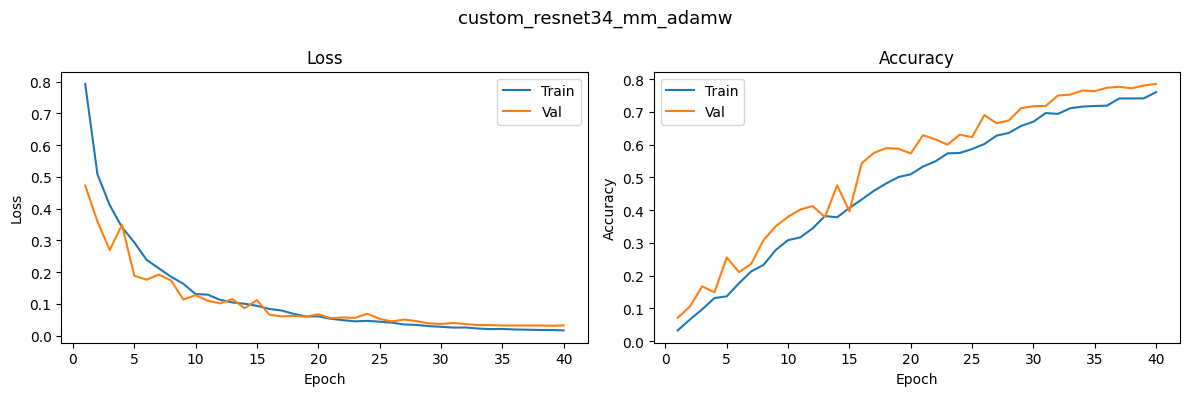

Checkpoint saved: checkpoints_ResNets_2026/custom_resnet34_mm_adamw.pt
custom_resnet18_mm_adamw->7.915793160597484
custom_resnet34_mm_adamw->17.064320059617362


In [ ]:
results_summary = []
trained_models = {}
all_histories = {}
all_time = {}

for run_name, model_fn, loss_name, optim_name, lr, flag_pretrained in exp:
    print("-------------------------------------")
    print(f"Run: {run_name}")
    print(f"Loss: {loss_name}  |  Optimizer: {optim_name}  |  LR: {lr}")
    print("----------------------------------------------")
    
    if flag_pretrained:
        train_loader_use = train_loader_pre_trained
        val_loader_use = val_loader_pre_trained
    else:
        train_loader_use = train_loader
        val_loader_use = val_loader

    model = model_fn().to(DEVICE)
    criterion = build_criterion(loss_name)
    optimizer = build_optimizer(optim_name, model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=lr * 0.01)

    model, history, time_var = train_model(model, train_loader_use, val_loader_use, criterion, optimizer, scheduler=scheduler, run_name=run_name)

    _, _, labels, preds, logits = evaluate(model, val_loader_use, criterion, DEVICE)
    metrics = compute_metrics(labels, preds, logits, name=run_name)

    results_summary.append({
        "run"         : run_name,
        "loss"        : loss_name,
        "optimizer"   : optim_name,
        "lr"          : lr,
        **metrics
    })
    trained_models[run_name] = model
    all_histories[run_name]  = history
    all_time[run_name] = time_var

    plot_history(history, title=run_name)

    os.makedirs(f"../checkpoints_ResNets/checkpoints_ResNets_{SEED}", exist_ok=True)
    torch.save({
        "model_state" : model.state_dict(),
        "history" : history,
        "metrics" : metrics,
    }, f"../checkpoints_ResNets/checkpoints_ResNets_{SEED}/{run_name}.pt")
    print(f"Checkpoint saved: checkpoints_ResNets_{SEED}/{run_name}.pt")


# Analysis of Results

> **Note:** This notebook evaluates a specific subset of experimental runs. For the full performance analysis of all models, please refer to the following directory:  
> `../support/checkpoint_analysis` and define FLAG = 1

In [25]:
df_results = pd.DataFrame(results_summary).sort_values("accuracy", ascending=False)
df_results = df_results.reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results.to_string(index=False))

                     run         loss optimizer     lr  accuracy  f1_macro  f1_weighted
custom_resnet18_mm_adamw multi_margin     adamw 0.0010    0.7865    0.7828       0.7849
custom_resnet34_mm_adamw multi_margin     adamw 0.0010    0.7808    0.7771       0.7783


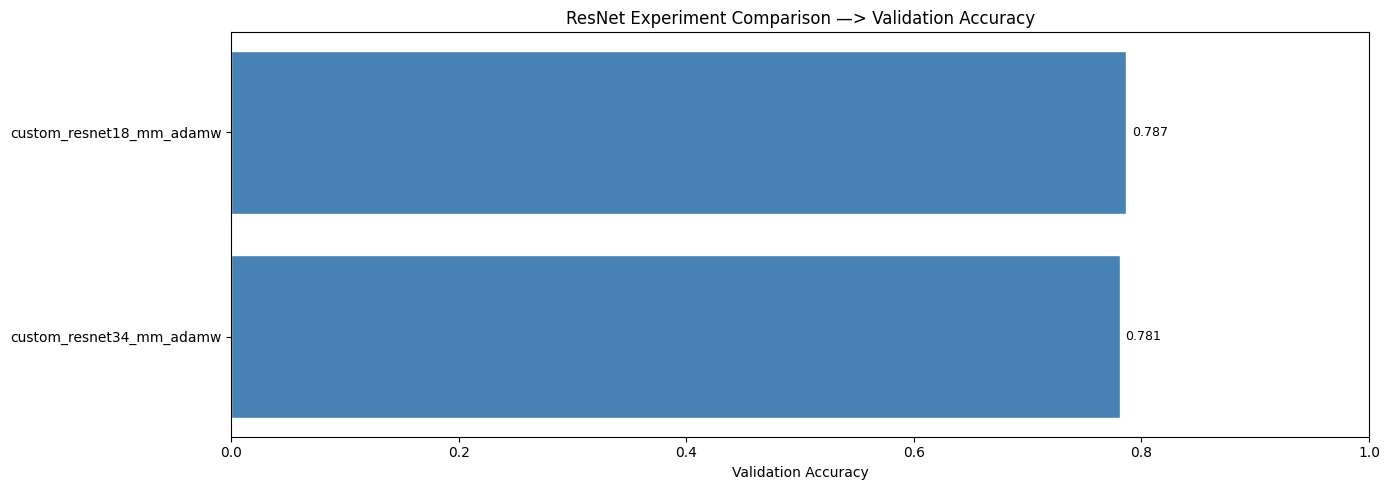

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(df_results["run"][::-1], df_results["accuracy"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Validation Accuracy")
ax.set_title("ResNet Experiment Comparison —> Validation Accuracy")
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, df_results["accuracy"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
best_run  = df_results.iloc[0]["run"]
best_model = trained_models[best_run]
print(f"Best model: {best_run}\n")

best_loss_name = df_results.iloc[0]["loss"]
criterion_best = build_criterion(best_loss_name)


if best_run.startswith("pretrained"):
    val_loader_use = val_loader_pre_trained
else:
    val_loader_use = val_loader

_, _, labels, preds, = evaluate(best_model, val_loader_use, criterion_best, DEVICE)

print(classification_report(labels, preds, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], zero_division=0))

Best model: custom_resnet18_mm_adamw

                           precision    recall  f1-score   support

                   ADONIS       0.76      0.93      0.84        14
AFRICAN GIANT SWALLOWTAIL       1.00      0.92      0.96        12
           AMERICAN SNOOT       0.71      0.83      0.77        12
                    AN 88       1.00      0.93      0.96        14
                  APPOLLO       1.00      0.86      0.92        14
                    ATALA       1.00      0.88      0.93        16
 BANDED ORANGE HELICONIAN       0.86      0.75      0.80        16
           BANDED PEACOCK       0.73      0.62      0.67        13
            BECKERS WHITE       0.46      0.46      0.46        13
         BLACK HAIRSTREAK       0.87      0.93      0.90        14
              BLUE MORPHO       0.73      0.67      0.70        12
        BLUE SPOTTED CROW       0.65      0.79      0.71        14
           BROWN SIPROETA       0.83      0.94      0.88        16
            CABBAGE WHI

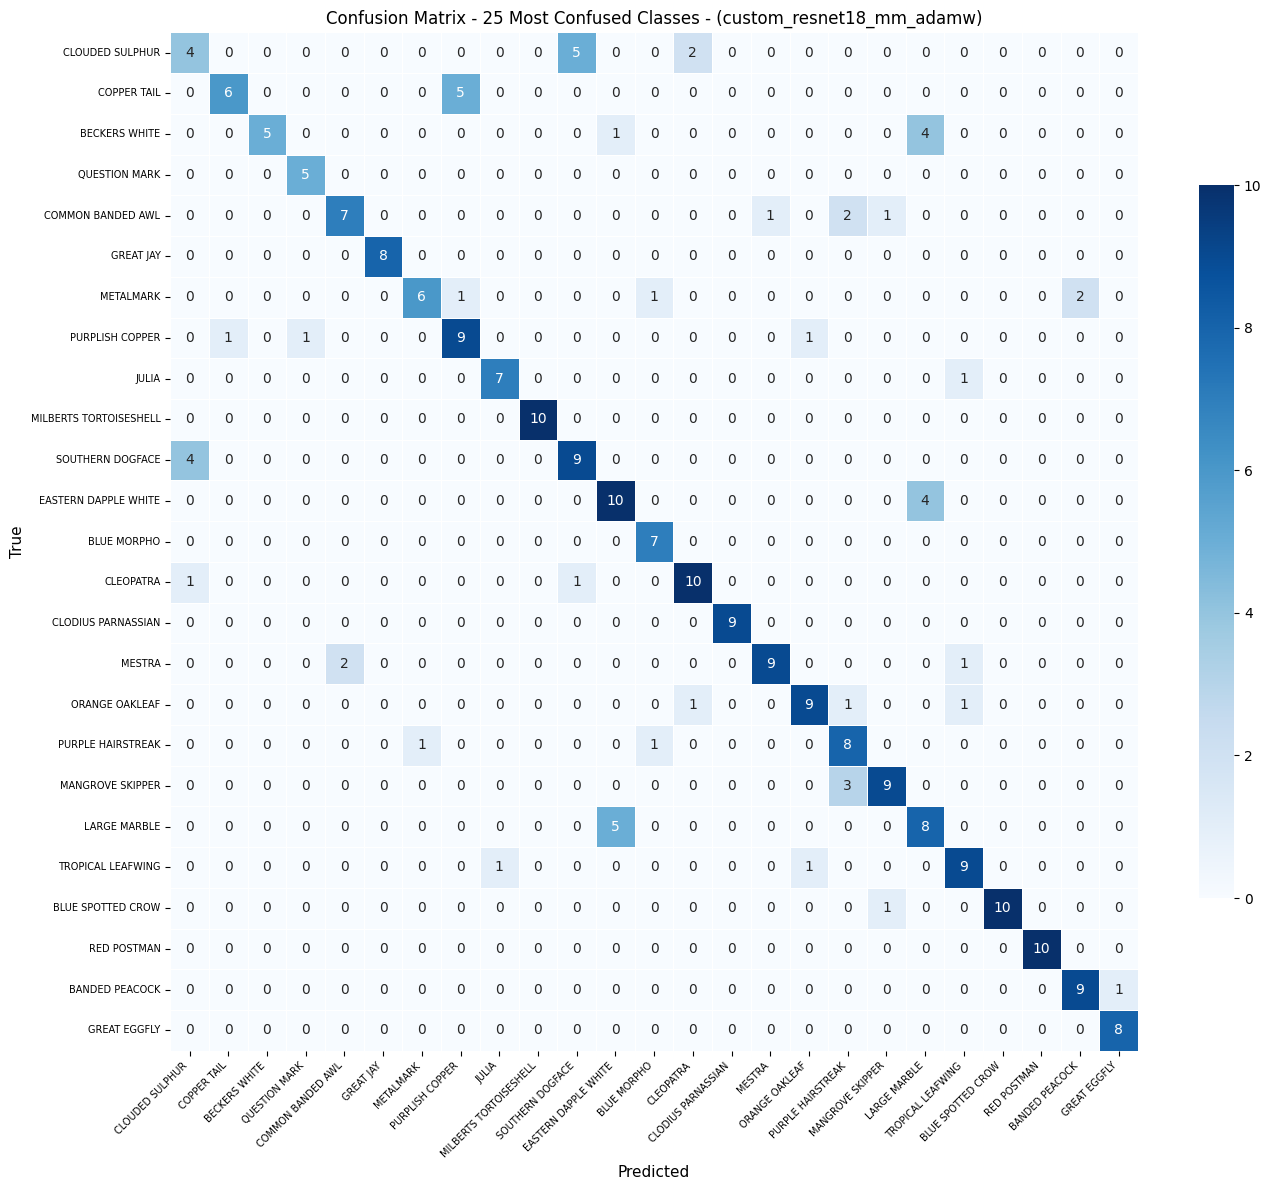

In [29]:
cm = confusion_matrix(labels, preds)

errors_per_class = cm.sum(axis=1) - cm.diagonal()
top25_idx = np.argsort(errors_per_class)[-25:][::-1]

cm_top25    = cm[np.ix_(top25_idx, top25_idx)]
class_names = [idx_to_class[i] for i in top25_idx]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_top25, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.4, cbar_kws={"shrink": 0.7})
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Confusion Matrix - 25 Most Confused Classes - ({best_run})")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_902973/712109069.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


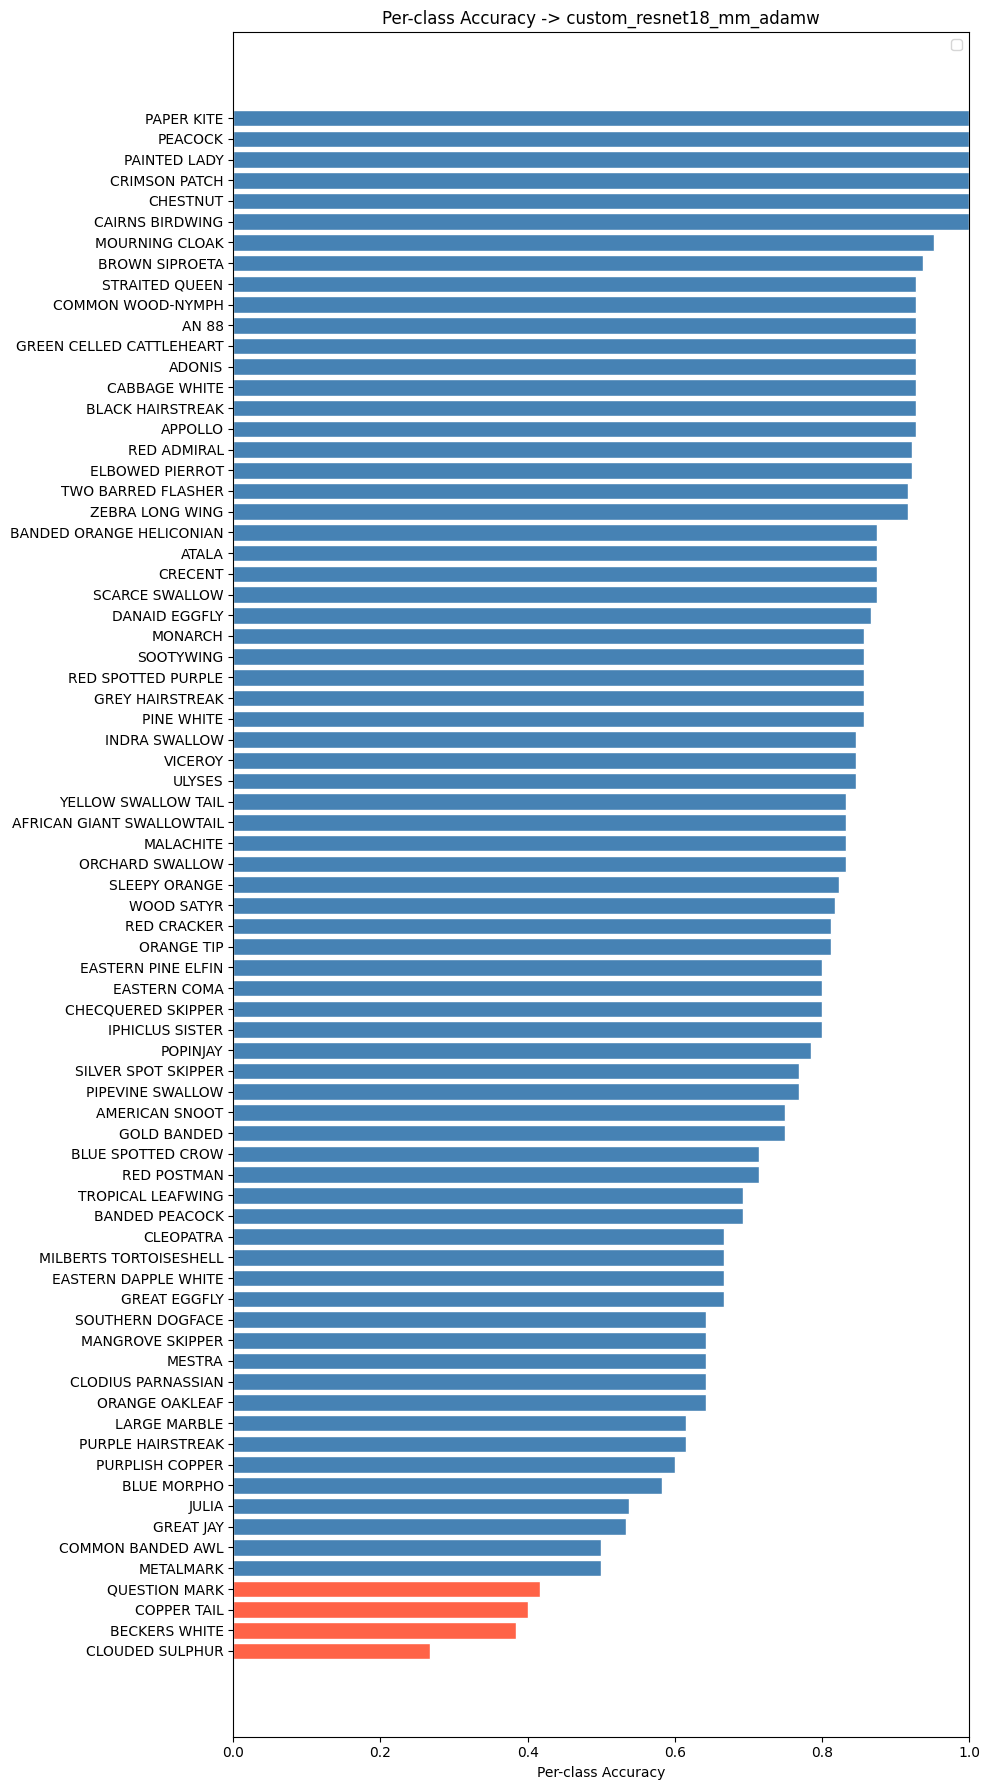

In [30]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

sorted_idx = np.argsort(per_class_acc)
sorted_acc = per_class_acc[sorted_idx]
sorted_names = [idx_to_class[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 18))
colors = ["tomato" if a < 0.5 else "steelblue" for a in sorted_acc]
ax.barh(sorted_names, sorted_acc, color=colors, edgecolor="white")
ax.set_xlabel("Per-class Accuracy")
ax.set_title(f"Per-class Accuracy -> {best_run}")
ax.set_xlim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()